# Homework 2: Tilt Dynamics with PD Control and ML-Ready Dataset

## Objective
This notebook develops a physics-based simulator for vehicle tilt dynamics using a PD controller.

The goal is to **minimize lateral acceleration felt by the passenger**, while also considering actuator effort.

---

## Governing Equations

Lateral acceleration:
$$
a_{lat} = \frac{v^2}{R}
$$

Desired tilt:
$$
\phi_{des} = \tan^{-1}\left(\frac{a_{lat}}{g}\right)
$$

Felt acceleration:
$$
a_{felt} = \frac{v^2}{R} - g \sin(\phi)
$$

---

## Control Law (PD Control)

$$
\ddot{\phi} = k_p(\phi_{des} - \phi) - k_{rate}\dot{\phi}
$$

---

## Objectives
- Minimize $a_{felt}$
- Keep actuator effort reasonable

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd

In [1]:
params = {
    "g": 9.81,
    "kp": 5.0,
    "krate": 2.0
}

In [2]:
def tilt_dynamics_control(t, state, v, R, params):
    phi, phi_dot = state

    g = params["g"]
    kp = params["kp"]
    krate = params["krate"]

    a_lat = v**2 / R
    phi_des = np.arctan(a_lat / g)

    phi_ddot = kp * (phi_des - phi) - krate * phi_dot

    return [phi_dot, phi_ddot]

## Physics-Based Simulation

The system dynamics are solved using numerical integration. The simulator produces time histories of tilt angle and felt acceleration.

In [3]:
def simulate_case(v, R, params, t_final=5.0):

    t_eval = np.linspace(0, t_final, 200)

    sol = solve_ivp(
        lambda t, y: tilt_dynamics_control(t, y, v, R, params),
        [0, t_final],
        [0, 0],
        t_eval=t_eval
    )

    phi = sol.y[0]
    phi_dot = sol.y[1]
    t = sol.t

    a_lat = v**2 / R
    a_felt = a_lat - params["g"] * np.sin(phi)

    effort = np.gradient(phi_dot, t)

    return {
        "t": t,
        "phi": phi,
        "a_felt": a_felt,
        "effort": effort
    }

## Example Simulation

The following plot shows the time evolution of the system for a sample case.

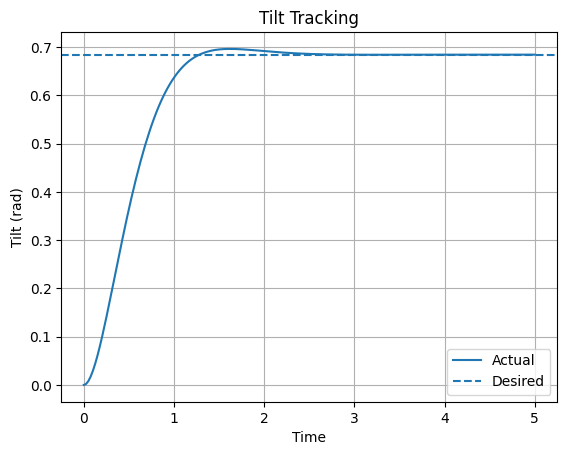

In [18]:
res = simulate_case(20, 50, params)

phi_des = np.arctan((20**2 / 50) / params["g"])

plt.plot(res["t"], res["phi"], label="Actual")
plt.axhline(phi_des, linestyle="--", label="Desired")

plt.title("Tilt Tracking")
plt.xlabel("Time")
plt.ylabel("Tilt (rad)")
plt.legend()
plt.grid()
plt.savefig("sim_tilt_tracking", dpi=300, bbox_inches='tight')
plt.show()

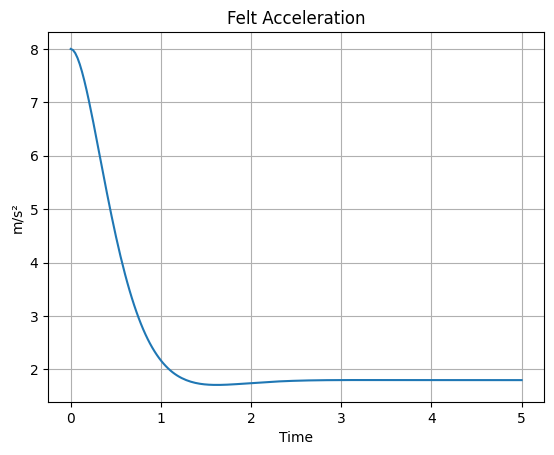

In [19]:
plt.plot(res["t"], res["a_felt"])
plt.title("Felt Acceleration")
plt.xlabel("Time")
plt.ylabel("m/s²")
plt.grid()
plt.savefig("ssim_felt_acceleration", dpi=300, bbox_inches='tight')

plt.show()

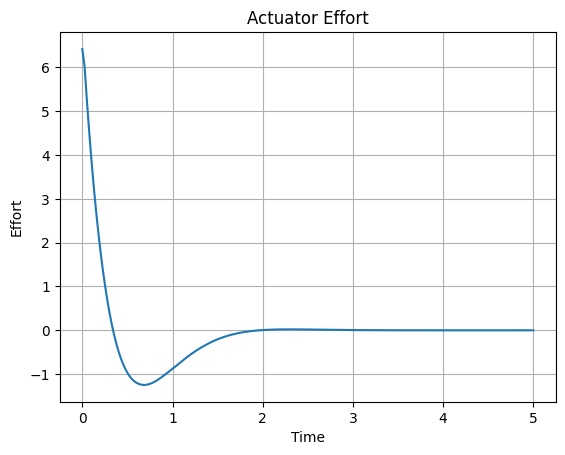

In [20]:
plt.plot(res["t"], res["effort"])
plt.title("Actuator Effort")
plt.xlabel("Time")
plt.ylabel("Effort")
plt.grid()
plt.savefig("sim_actuator_effort", dpi=300, bbox_inches='tight')

plt.show()

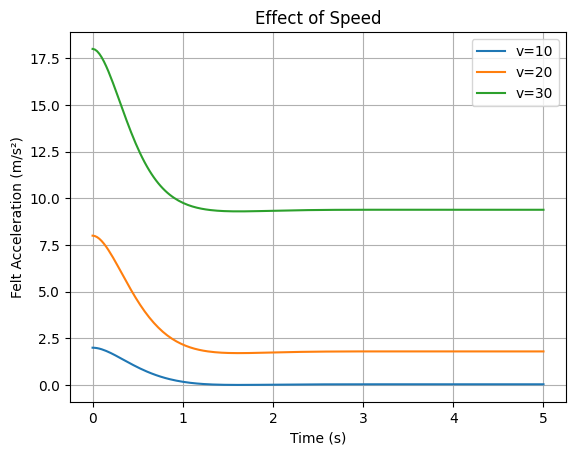

In [21]:
 for v in [10, 20, 30]:
    r = simulate_case(v, 50, params)
    plt.plot(r["t"], r["a_felt"], label=f"v={v}")

plt.title("Effect of Speed")

plt.xlabel("Time (s)")
plt.ylabel("Felt Acceleration (m/s²)")

plt.legend()
plt.grid()
plt.savefig("sim_speed_effect", dpi=300, bbox_inches='tight')

plt.show()

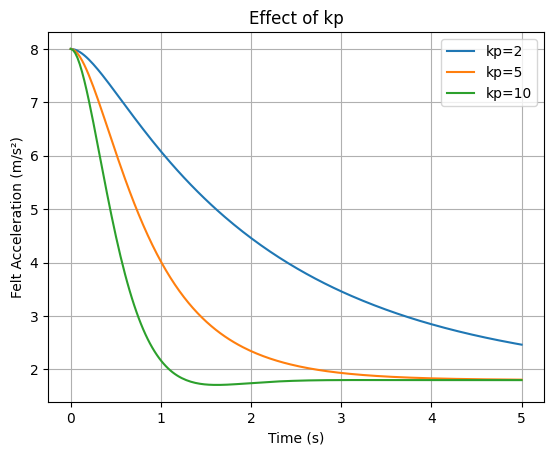

In [22]:
for kp in [2, 5, 10]:
    params["kp"] = kp
    r = simulate_case(20, 50, params)
    plt.plot(r["t"], r["a_felt"], label=f"kp={kp}")

plt.title("Effect of kp")
plt.xlabel("Time (s)")
plt.ylabel("Felt Acceleration (m/s²)")

plt.legend()
plt.grid()
plt.savefig("sim_kp_effect", dpi=300, bbox_inches='tight')

plt.show()

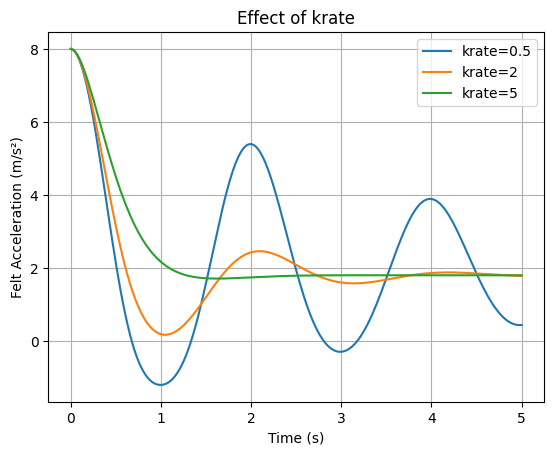

In [23]:
for kr in [0.5, 2, 5]:
    params["krate"] = kr
    r = simulate_case(20, 50, params)
    plt.plot(r["t"], r["a_felt"], label=f"krate={kr}")

plt.title("Effect of krate")
plt.xlabel("Time (s)")
plt.ylabel("Felt Acceleration (m/s²)")

plt.legend()
plt.grid()
plt.savefig("sim_krate_effect", dpi=300, bbox_inches='tight')

plt.show()

## Synthetic Data Generation

A dataset is generated by sampling across velocity, radius, and control gains.

Each sample stores:
- Input: (v, R, kp, krate)
- Output: maximum felt acceleration

In [13]:
data = []

for v in np.linspace(5, 30, 10):
    for R in np.linspace(20, 100, 10):
        for kp in np.linspace(2, 10, 10):
            for kr in np.linspace(0.5, 5, 10):

                params["kp"] = kp
                params["krate"] = kr

                res = simulate_case(v, R, params)

                data.append({
                    "v": v,
                    "R": R,
                    "kp": kp,
                    "krate": kr,
                    "max_felt": np.max(np.abs(res["a_felt"])),
                    "effort": np.mean(np.abs(res["effort"]))
                })

df = pd.DataFrame(data)
df.to_csv("dataset.csv", index=False)

df.head()

,v,R,kp,krate,max_felt,effort
0,5.0,20.0,2.0,0.5,1.25,0.094340
1,5.0,20.0,2.0,1.0,1.25,0.060586
2,5.0,20.0,2.0,1.5,1.25,0.043537
3,5.0,20.0,2.0,2.0,1.25,0.034220
4,5.0,20.0,2.0,2.5,1.25,0.029069
